
========== TASK 1 ==========
Input Product: Sports Shoes

Recommended Products:
- Sports Socks
- Fitness Watch
- Water Bottle

========== TASK 2 ==========
Original Catalog Size: 500
Unique Catalog Size: 270

========== TASK 3 ==========
Query: blue casual shirt
1. 57281.jpg | Score=0.2998
2. 25540.jpg | Score=0.2963
3. 13333.jpg | Score=0.2952
4. 4772.jpg | Score=0.2932
5. 12267.jpg | Score=0.2924


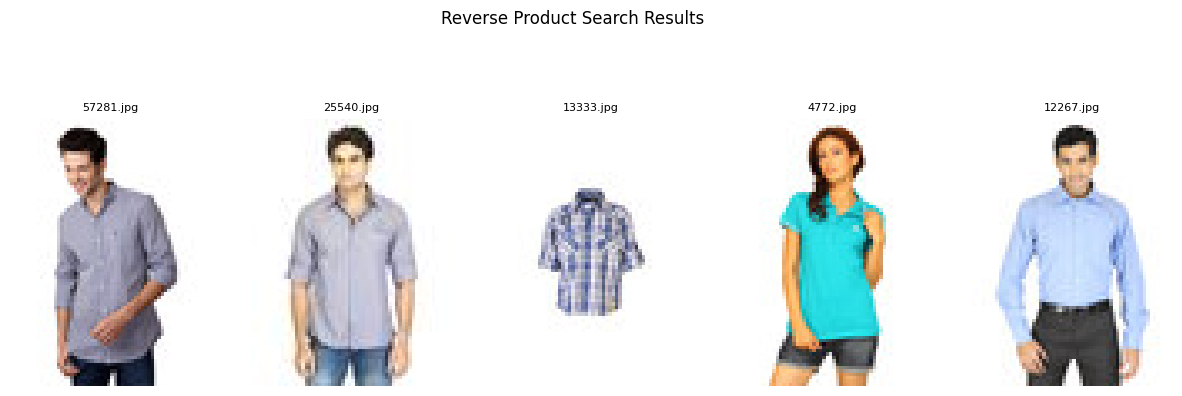


========== SUMMARY ==========
Task 1 Completed ✓
Task 2 Completed ✓
Task 3 Completed ✓


In [21]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

def show_results(paths, title="Results"):

    plt.figure(figsize=(15,5))
    plt.suptitle(title)

    for i, path in enumerate(paths):

        img = Image.open(path)

        plt.subplot(1, len(paths), i + 1)
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            os.path.basename(path),
            fontsize=8
        )

    plt.show()


COMPLEMENTARY_MAP = {
    "Sports Shoes": [
        "Sports Socks",
        "Fitness Watch",
        "Water Bottle"
    ],
    "Casual Shoes": [
        "Jeans",
        "Tshirts",
        "Socks"
    ],
    "Shirts": [
        "Trousers",
        "Belts",
        "Formal Shoes"
    ],
    "Tshirts": [
        "Jeans",
        "Caps",
        "Sneakers"
    ],
    "Dresses": [
        "Heels",
        "Clutch",
        "Necklace"
    ]
}


def recommend_complementary_products():

    print("\n========== TASK 1 ==========")

    product_type = "Sports Shoes"

    recommendations = COMPLEMENTARY_MAP.get(
        product_type,
        ["Backpack", "Cap", "Socks"]
    )

    print("Input Product:", product_type)

    print("\nRecommended Products:")

    for item in recommendations:
        print("-", item)

    return recommendations


def create_unique_catalog(
    embeddings,
    paths,
    similarity_threshold=0.92
):

    print("\n========== TASK 2 ==========")

    sim_matrix = cosine_similarity(
        embeddings
    )

    distance_matrix = np.clip(
        1 - sim_matrix,
        0,
        1
    )

    clustering = DBSCAN(
        eps=1 - similarity_threshold,
        min_samples=1,
        metric="precomputed"
    )

    labels = clustering.fit_predict(
        distance_matrix
    )

    unique_catalog = []

    for label in set(labels):

        idx = np.where(
            labels == label
        )[0][0]

        unique_catalog.append(
            paths[idx]
        )

    print("Original Catalog Size:",
          len(paths))

    print("Unique Catalog Size:",
          len(unique_catalog))

    return unique_catalog


def search_products(
    query,
    embeddings,
    paths,
    top_k=5
):

    print("\n========== TASK 3 ==========")

    text_tokens = tokenizer(
        [query]
    ).to(device)

    with torch.no_grad():

        text_embedding = model.encode_text(
            text_tokens
        )

    text_embedding = (
        text_embedding.cpu().numpy()
    )

    text_embedding = (
        text_embedding /
        np.linalg.norm(
            text_embedding,
            axis=1,
            keepdims=True
        )
    )

    similarities = cosine_similarity(
        text_embedding,
        embeddings
    )[0]

    top_indices = similarities.argsort()[
        -top_k:
    ][::-1]

    results = []

    print("Query:", query)

    for rank, idx in enumerate(top_indices):

        print(
            f"{rank+1}. "
            f"{os.path.basename(paths[idx])}"
            f" | Score={similarities[idx]:.4f}"
        )

        results.append(
            paths[idx]
        )

    return results


recommendations = recommend_complementary_products()

unique_catalog = create_unique_catalog(
    image_embeddings,
    valid_image_paths
)

search_results = search_products(
    "blue casual shirt",
    image_embeddings,
    valid_image_paths
)

show_results(
    search_results,
    title="Reverse Product Search Results"
)

print("\n========== SUMMARY ==========")
print("Task 1 Completed ✓")
print("Task 2 Completed ✓")
print("Task 3 Completed ✓")